<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Simulaci-n_II/blob/main/Prob_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from random import gauss
from math import sqrt
import numpy as np
import matplotlib.pyplot as plt

def genera(x0,u,o,c,delta,n):
    oo=sqrt(delta)
    l=np.zeros(n)
    l[0]=x0
    for i in range(n-1):
        x=l[i]
        t=0
        while t<1:
            w=oo*gauss(0,1)
            x=x+c*(x-u)*delta+o*w
            t=t+delta
        l[i+1]=x
    return l

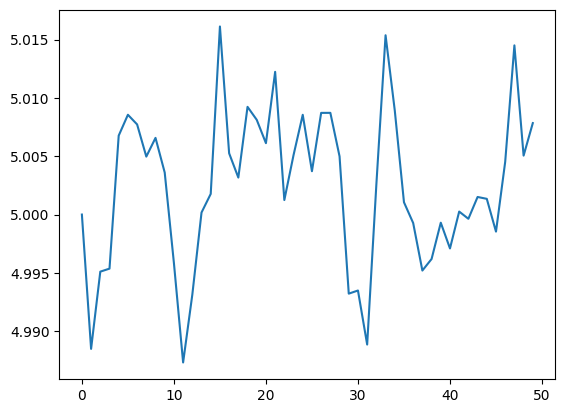

In [8]:
c=-0.8
u=5
o=0.01
x0=u
delta=0.001
n=50
l=genera(x0,u,o,c,delta,n)
plt.plot(l)
plt.show()

In [32]:
x0=np.array([4.7,0.005,-.7])
delta=0.01
ns=10000
res=minimize(L,x0,args=(l,delta,ns),method='Nelder-Mead')
print(res)

 4.70000  0.00500 -0.70000 -460.51702
 4.93500  0.00500 -0.70000 -106.14518
 4.70000  0.00525 -0.70000 -460.51702
 4.70000  0.00500 -0.73500 -460.51702
 4.85667  0.00517 -0.66500 -460.51702
 4.73917  0.00504 -0.71750 -460.51702
 4.81750  0.00500 -0.70000 -460.51702
 4.81750  0.00513 -0.70000 -460.51702
 4.81750  0.00500 -0.71750 -460.51702
 4.89583  0.00508 -0.68250 -260.85485
 4.94806  0.00493 -0.68833 -63.70259
 5.01333  0.00483 -0.68250  4.53746
 5.07861  0.00494 -0.67667 -29.85550
 5.12213  0.00477 -0.69028 -176.42823
 5.06556  0.00485 -0.68833 -12.75767
 5.17000  0.00475 -0.66500 -407.59533
 4.99375  0.00494 -0.69125  2.02975
 4.96981  0.00480 -0.69806 -20.45848
 4.99701  0.00484 -0.69271  2.86255
 4.93718  0.00489 -0.68931 -97.05484
 5.03346  0.00486 -0.68858  2.46290
 5.03546  0.00475 -0.68461  2.25157
 5.02503  0.00480 -0.68627  3.42727
 4.99012  0.00479 -0.68574  0.55661
 5.02263  0.00484 -0.68787  3.74239
 5.04365  0.00481 -0.67838  1.66536
 5.00867  0.00483 -0.68913  4.33417

In [35]:
from random import gauss, seed
from math import sqrt, log, pi, exp
import numpy as np
import matplotlib.pyplot as plta
from scipy.stats import gaussian_kde
from scipy.optimize import minimize
from numba import jit
@jit(nopython=True)

def k(s):
    return(1/sqrt(2*pi))*exp(-s**2/2)

@jit(nopython=True)

def pdf(x,l):
    n=len(l)
    h=1.06*np.std(l)/(n**.2)
    suma=0
    for i in range(n):
        suma=suma+K((x-1[i])/h)
    return suma/(n*h)

def L(x, l, delta, ns): # Added 'x' as the first argument
    seed(43)
    u=x[0]
    o=x[1]
    c=x[2]
    oo=sqrt(delta)
    n=len(l)
    suma=0
    val_sim = np.zeros(n-1)
    for j in range(n-1):
        s=l[j] # Renamed x to x_current to avoid conflict with function parameter x
        t=0
        while t<1:
            w=oo*gauss(0,1)
            s=s+c*(s-u)*delta+o*w
            t=t+delta
        val_sim[j]=s
    valor=pdf(l[i+1])
    if valor<1e-200:
        valor=1e-200
    suma=suma+log(valor)
    #print("%8.5f"%u,"%8.5f"%o,"%8.5f"%c,"%8.5f"%(suma))
    return -suma

<>:20: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
<>:20: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
/tmp/ipykernel_1792/2309481738.py:20: SyntaxWarning: 'int' object is not subscriptable; perhaps you missed a comma?
  suma=suma+K((x-1[i])/h)
